# Introduction

This document is created to get you familiar with my horrible codes from this pedestrian crowd project. You can tell how horrible and unorganized I was based on the number of random notebooks I've prototyped throughout the last 1-2 year or so. But ignore those notebooks for now, as hopefully this notebook alone (with some debugging) should be able to get you the necessary components of a complete pipeline that will: 
1. Load the spatio-temporal crowd flow graphs
    This graph dataset was created by integrating spatial and temporal information in the previous paper V. W. H. Wong and K. H. Law, Fusion of CCTV Video and Spatial Information for Automated Crowd Congestion Monitoring in Public Urban Spaces. Algorithms, Mar 2023, 16(3):154. https://doi.org/10.3390/a16030154. As opposed to this previous paper which relies only on one single-camera dataset to do the crowd flow estimation, there are two more self-collected data sources now integrated with multiple cameras. 
2. Prediction
3. Visualization of hostpots 

Proposed title of a publication resulting from this line of work could be something along the lines of: 
"ST-DIF: A spatio-temporal data integration framework to estimate pedestrian crowd flow from multi-camera surveillance in built environments"


# 0. Setup environment

## 0.1 set up a conda environment following the README instructions

## 0.2. Import packages

In [3]:
import os
import sys
import torch

from tqdm.notebook import tqdm # might have to install this if you don't have it

# for relative imports
os.chdir('..') 
print(os.getcwd()) # should print /your_local_dir/crowd-framework

from st_dif.data_utils import get_pyg_temporal_dataset, get_loaders
from st_dif.models import DenseGCNGRU, GCNGRU, GRU_only
from st_dif import train, evaluate, save_or_update_checkpoint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # should say 'cpu' if you're using mac.
print(device)

c:\Users\haryd\crowd-framework
cuda


In [4]:
class Args:
    def __init__(self):
        self.DATASET = 'Stadium'
        self.forecasting_horizon = 20

args = Args()

# 0.3 Try running the two demo notebooks from Campus Crowd subset before moving on

# 1. Crowd Flow Dataset
We have 2 subsets of data in this framework: GCS (a public one), Campus Crowd ( collected at Stanford). Both were videos but post-processed with CNN to detect and track pedestrian info. 

1. The first subset, Campus Crowd, is the original pedestrian data I collected back at Stanford was videos. Due to IRB regulations they are anonymised and are stored in CSV. They are available to public use at https://github.com/vivian-wong/Campus-Crowd. I recently cleanedup the campus crowd repo, so the get_pyg_temporal_dataset function is much more well-developed. Most files in this repo are from the campus crowd repo, but i reorganized some files for clarity. 

2. The second subset, Grand Central Station (GCS), is a public dataset. GCS will be loaded using the class GCSDatasetLoaderStatic. It is very ugly right now and I hope to have it integrated into this repo just like the campus crowd data. 

## 1.1. Getting familiar with the more well-developed campus crowd dataset loader 

You've seen in the demo_dataset notebook how we can call get_pyg_temporal_dataset

In [5]:
dataset, cmgraph = get_pyg_temporal_dataset(args.DATASET, args.forecasting_horizon)

Dataset type:   <torch_geometric_temporal.signal.static_graph_temporal_signal.StaticGraphTemporalSignal object at 0x00000121785A3190>
Number of samples / sequences:  2356
Data(x=[6, 2, 20], edge_index=[2, 10], edge_attr=[10], y=[6, 20])


get_pyg_temporal_dataset currently ONLY SUPPORTS the campus crowd subset. The function is pasted below for your reference (from data_utils.py): 
```python
import configparser
from st_dif.cmgraph import CMGraph

config_file_paths = {
    'SEQ':    './crowd-framework/data/campus-crowd-processed/SEQ.cfg', 
    'Stadium':'./crowd-framework/data/campus-crowd-processed/Stadium_2023.cfg'
}

def get_pyg_temporal_dataset(DATASET, forecasting_horizon): 
    '''
    Parameters:
        raise ValueError(f"DATASET must be one of: {', '.join(config_file_paths.keys())}")
    forecasting_horizon (int): The number of timesteps for forecasting.

    Returns:
    torch_geometric_temporal.signal.StaticGraphTemporalSignal: 
        A static graph temporal signal object containing the dataset.
    '''

    if DATASET not in config_file_paths.keys():
        raise ValueError("DATASET must be one of: ", config_file_paths.keys())
    
    configs_dict = get_configs_dict(config_file_paths[DATASET])
    flow_df = pd.read_csv(configs_dict['csv-path']['flow_df_path'])
    ... # irrelevant lines ommitted for conciseness
``` 
Essentially, as long as there is a config file supplied in the config_file_paths directory, the get_pyg_temporal_dataset function will parse the config file and read the crowd flow data csv in the config file. There's a lot of irrelevant information in the config file on original video data. But the most important part is below (for Stadium scenario, as an example): 
```python
[csv-path]
flow_df_path = ./campuscrowd/data_processed/flow_df_stadium_2023_1fps.csv

[CMGraph]
adjacency_mat = 0,1,0,0,0,0
                1,0,1,0,0,0
                0,1,0,1,0,0
                0,0,1,0,1,0
                0,0,0,1,0,1
                0,0,0,0,1,0
                
```
FYI, the csv contains the crowd flow data and it looks like this

In [6]:
cmgraph.flow_df

,timestamp,speed,num_people,cam_name,PAR_id,frame_number,raw_frame_number
0,0.0,NaN,1.0,Tunnel A,1,0.0,0.0
1,1.0,11.823683,2.0,Tunnel A,1,1.0,29.0
2,2.0,340.117319,2.0,Tunnel A,1,2.0,58.0
3,3.0,210.030362,1.0,Tunnel A,1,3.0,87.0
4,4.0,381.040588,1.0,Tunnel A,1,4.0,116.0
...,...,...,...,...,...,...,...
14770,2471.0,119.711735,8.0,Tunnel F,6,2471.0,71659.0
14771,2472.0,73.658169,6.0,Tunnel F,6,2472.0,71688.0
14772,2473.0,79.251304,5.0,Tunnel F,6,2473.0,71717.0
14773,2474.0,106.736505,4.0,Tunnel F,6,2474.0,71746.0


However, right now, data from the GCS scenario cannot be loaded with the above code. The reason is that it is a public dataset that comes with the 'data/gcs/Annotation/' folder, which is a completely different format compared to the above one from campus crowd. So, I created a dataset class just for GCS as a temporary solution.

## 1.2. GCS dataset class

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy import interpolate
import torch
from torch_geometric.utils import dense_to_sparse


def image_to_world(p, Homog):
    pp = np.hstack((p, np.ones((p.shape[0], 1))))
    PP = (Homog @ pp.T).T  # Matrix multiplication; shape becomes (N, 3)
    P_normal = PP / PP[:, 2:3]  # Normalize by the third coordinate
    return P_normal[:, :2] * 0.8

def parse_gcs(path):
  
    HOMOG = np.array([[4.97412897e-02, -4.24730883e-02, 7.25543911e+01],
                      [1.45017874e-01, -3.35678711e-03, 7.97920970e+00],
                      [1.36068797e-03, -4.98339188e-05, 1.00000000e+00]])
    FPS = 25
    FRAME_STEPSIZE = 20
    
    raw_data_list = []
    file_list = sorted(os.listdir(path))
    
    for annot_file in file_list:
        annot_file_full_path = os.path.join(path, annot_file)
        with open(annot_file_full_path, 'r') as f:
            annot_contents = f.read().split()
        agent_id = int(os.path.splitext(annot_file)[0])
        
        for i in range(len(annot_contents) // 3):
            py = float(annot_contents[3 * i])
            px = float(annot_contents[3 * i + 1])
            frame_id = int(annot_contents[3 * i + 2])
            raw_data_list.append([frame_id, agent_id, px, py])
    
    df_columns = ["frame_id", "agent_id", "pos_x", "pos_y"]
    raw_data_frame = pd.DataFrame(np.array(raw_data_list), columns=df_columns)
    
    # Group trajectories by agent id
    grouped = raw_data_frame.groupby("agent_id")
    trajs = [group for _, group in grouped]
    
    # For each agent trajectory, resample (interpolate) the positions on a uniform frame grid.
    temp_df = pd.DataFrame(columns=["frame_id", "agent_id", "pos_x", "pos_y"])
    for tr in trajs:
        if len(tr) < 2:
            continue  # Skip too-short trajectories
        interp_F = np.arange(tr["frame_id"].iloc[0], tr["frame_id"].iloc[-1], FRAME_STEPSIZE).astype(int)
        interp_func_x = interpolate.interp1d(tr["frame_id"], tr["pos_x"], kind='linear')
        interp_func_y = interpolate.interp1d(tr["frame_id"], tr["pos_y"], kind='linear')
        interp_X = interp_func_x(interp_F)
        interp_Y = interp_func_y(interp_F)
        agent_id = int(tr["agent_id"].iloc[0])
        temp_df = pd.concat([temp_df,
                             pd.DataFrame({"frame_id": interp_F,
                                           "agent_id": agent_id,
                                           "pos_x": interp_X,
                                           "pos_y": interp_Y})])
    raw_data_frame = temp_df.reset_index(drop=True)
    
    # Save original image coordinates (if needed) and then project to world coordinates
    raw_data_frame[["img_x", "img_y"]] = raw_data_frame[["pos_x", "pos_y"]]
    world_coords = image_to_world(raw_data_frame[["pos_x", "pos_y"]].to_numpy(), HOMOG)
    raw_data_frame[["pos_x", "pos_y"]] = pd.DataFrame(world_coords, columns=["pos_x", "pos_y"])
    
    # Compute a timestamp for each frame
    raw_data_frame["timestamp"] = raw_data_frame["frame_id"] / FPS
    
    # Compute velocities for each agent (difference between consecutive positions)
    raw_data_frame["vel_x"] = raw_data_frame.groupby("agent_id")["pos_x"].diff()
    raw_data_frame["vel_y"] = raw_data_frame.groupby("agent_id")["pos_y"].diff()
    raw_data_frame["timestamp_diff"] = raw_data_frame.groupby("agent_id")["timestamp"].diff()
    raw_data_frame["vel_x"] = raw_data_frame["vel_x"] / raw_data_frame["timestamp_diff"]
    raw_data_frame["vel_y"] = raw_data_frame["vel_y"] / raw_data_frame["timestamp_diff"]
    raw_data_frame["vel_x"].fillna(method="bfill", inplace=True)
    raw_data_frame["vel_y"].fillna(method="bfill", inplace=True)
    
    # Regroup by agent_id and return the list of trajectories (DataFrames)
    grouped = raw_data_frame.groupby("agent_id")
    trajs = [group for _, group in grouped]
    return trajs


class GCSDatasetLoaderStatic(): 
    
    def __init__(self, trajs, ZONE_LIST):
        self.trajs = trajs
        self.ZONE_LIST = ZONE_LIST
        self._read_data()
        
    def _read_data(self): 
        # Determine delta_t using the first trajectory's timestamps
        delta_t = self.trajs[0]['timestamp'].iloc[1] - self.trajs[0]['timestamp'].iloc[0]
        all_trajs = pd.concat(self.trajs)
        # Compute speed as the Euclidean norm of (vel_x, vel_y)
        all_trajs['speed'] = np.sqrt(all_trajs['vel_x']**2 + all_trajs['vel_y']**2)
        self.all_trajs = all_trajs
        
        # Build the adjacency matrix for the zones (nodes)
        num_nodes = len(self.ZONE_LIST)
        A = np.ones((num_nodes, num_nodes))
        A -= np.eye(num_nodes)
        A[0:2, 4:] = np.zeros_like(A[0:2, 4:])
        A[2:4, 6:] = np.zeros_like(A[2:4, 6:])
        A[4:6, 8] = np.zeros_like(A[4:6, 8])
        A = np.triu(A)
        A = A + A.T - np.diag(np.diag(A))
        
        # For each zone, extract trajectories inside the zone and compute average speed and count of people over time.
        zone_dfs = []
        common_time = [0, 1e6]
        for i in range(num_nodes): 
            x1, y1, x2, y2 = self.ZONE_LIST[i]
            tr = self.all_trajs[
                (self.all_trajs['pos_x'] > x1) & 
                (self.all_trajs['pos_x'] < x2) & 
                (self.all_trajs['pos_y'] > y1) & 
                (self.all_trajs['pos_y'] < y2)
            ]
            tr = tr.sort_values(by=['timestamp'])
            temp_df = pd.DataFrame(columns=["timestamp", "speed", "num_people"])
            for timestamp, group in tr.groupby("timestamp", as_index=False):
                mean_speed = group['speed'].mean()
                num_people = group['agent_id'].nunique()
                temp_df = pd.concat([temp_df,
                                     pd.DataFrame({"timestamp": [timestamp],
                                                   "speed": [mean_speed],
                                                   "num_people": [num_people]})])
            # Interpolate on a regular time grid
            if len(temp_df) < 2:
                continue
            interp_t = np.arange(temp_df["timestamp"].iloc[0], temp_df["timestamp"].iloc[-1], delta_t)
            interp_speed = interpolate.interp1d(temp_df["timestamp"], temp_df["speed"], kind='linear')(interp_t)
            interp_num_people = interpolate.interp1d(temp_df["timestamp"], temp_df["num_people"], kind='linear')(interp_t)
            zone_dfs.append(pd.DataFrame({"timestamp": interp_t,
                                          "speed": interp_speed,
                                          "num_people": interp_num_people}))
            common_time[0] = max(common_time[0], interp_t.min())
            common_time[1] = min(common_time[1], interp_t.max())
        
        # Crop the time series for each zone to a common time interval, and compute a normalized time feature.
        zone_dfs_cropped = []
        for i, df in enumerate(zone_dfs):
            df = df.round({'timestamp': 1})
            temp_df = df[(common_time[0] <= df['timestamp']) & (df['timestamp'] <= common_time[1])].copy()
            temp_df['cropped_time'] = (temp_df['timestamp'] - common_time[0]) / (common_time[1] - common_time[0])
            zone_dfs_cropped.append(temp_df[['num_people','cropped_time']].to_numpy().transpose([1,0]))
        X = np.stack(zone_dfs_cropped).astype(np.float32)
        
        # Normalize using Z-Score normalization (as in the DCRNN paper)
        means = np.mean(X, axis=(0, 2))
        X = X - means.reshape(1, -1, 1)
        stds = np.std(X, axis=(0, 2))
        X = X / stds.reshape(1, -1, 1)
        
        self.A = torch.from_numpy(A)
        self.X = torch.from_numpy(X)
        
        # Combine the zone DataFrames into one (adding a zone id 'PAR_id')
        zone_dfs_final = []
        for i, df in enumerate(zone_dfs):
            df['PAR_id'] = i
            zone_dfs_final.append(df)
        self.zone_dfs = pd.concat(zone_dfs_final, ignore_index=True)
        

data_dir = "./data/gcs"
trajs = parse_gcs(os.path.join(data_dir, "Annotation"))

PAR_LIST = [
    (0, 0, 28, 14),
    (28, 0, 55, 14),
    (0, 14, 28, 24),
    (28, 14, 55, 24),
    (0, 24, 28, 35),
    (28, 24, 55, 35),
    (0, 35, 28, 45),
    (28, 35, 55, 45),
    (0, 45, 55, 55)
]

dataset = GCSDatasetLoaderStatic(trajs=trajs, ZONE_LIST=PAR_LIST)

gcs_processed_dir = "./data/gcs/gcs-processed"
os.makedirs(gcs_processed_dir, exist_ok=True)
csv_file_path = os.path.join(gcs_processed_dir, "flow_df_gcs.csv")
dataset.zone_dfs.to_csv(csv_file_path, index=False)
print("CSV saved to:", csv_file_path)

cfg_content = "[csv-path]\n"
cfg_content += f"flow_df_path = {csv_file_path}\n\n"
cfg_content += "[CMGraph]\n"
A = dataset.A.numpy()

# Create a multi-line string where each row is comma-separated.
# Indent the subsequent lines so configparser treats them as part of the same value.
adjacency_mat_str = "\n    ".join([", ".join(map(str, row)) for row in A])

cfg_content += f"adjacency_mat = {adjacency_mat_str}\n"

cfg_file_path = os.path.join(gcs_processed_dir, "GCS.cfg")
with open(cfg_file_path, "w") as f:
    f.write(cfg_content)
print("Config file saved to:", cfg_file_path)



With the above two gigantic chunks of code, we can now get a GCS dataset object 

In [8]:
# might take a while to run. For my personal laptop it takes about 85 seconds.
data_dir = "./data/gcs"
trajs= parse_gcs(os.path.join(data_dir,"Annotation"))
PAR_LIST =[
    (0, 0, 28, 14),
    (28, 0, 55, 14),
    (0, 14, 28, 24),
    (28, 14, 55, 24),
    (0, 24, 28, 35),
    (28, 24, 55, 35),
    (0, 35, 28, 45),
    (28, 35, 55, 45),
    (0, 45, 55, 55)
]
dataset = GCSDatasetLoaderStatic(
    trajs=trajs,
    ZONE_LIST = PAR_LIST)

dataset.zone_dfs

C:\Users\haryd\AppData\Local\Temp\ipykernel_13756\3057154476.py:63: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  temp_df = pd.concat([temp_df, pd.DataFrame({"frame_id": interp_F,
C:\Users\haryd\AppData\Local\Temp\ipykernel_13756\3057154476.py:91: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_in

,num_people,cropped_time,timestamp,speed,PAR_id
0,1.0,0.000000,7.2,1.191813,0
1,1.0,0.000192,8.0,1.191813,0
2,1.0,0.000384,8.8,1.876111,0
3,1.0,0.000576,9.6,1.413016,0
4,1.0,0.000767,10.4,1.413016,0
...,...,...,...,...,...
46903,4.0,0.999041,4172.8,0.000963,8
46904,4.0,0.999233,4173.6,0.000963,8
46905,4.0,0.999424,4174.4,0.000963,8
46906,4.0,0.999616,4175.2,0.000963,8


<Axes: xlabel='timestamp'>

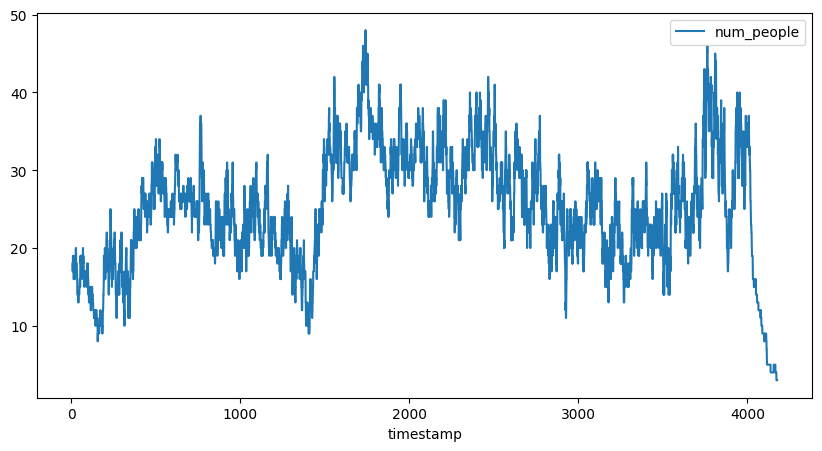

In [9]:
dataset.zone_dfs.query('PAR_id==5').plot(x='timestamp', y='num_people', figsize=(10,5))

C:\Users\haryd\AppData\Local\Temp\ipykernel_13756\1545916491.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  temp_df = pd.concat([temp_df,
C:\Users\haryd\AppData\Local\Temp\ipykernel_13756\1545916491.py:77: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_data_frame["vel_x"].

CSV saved to: ./data/gcs/gcs-processed\flow_df_gcs.csv
Config file saved to: ./data/gcs/gcs-processed\GCS.cfg


# 2. Tasks Remaining (in the order of priority)

## 2.1. Merge data from Grand Central Station, so that it's all one package that people can easily experiment with 



You see how chunky GCS is compared to campus crowd... This will be very confusing when we need to publish our code because it is so inconsistent with the other data subset... So I'd like to ask for your help to convert GCS to the same format as the campus crowd subset. It should (1) be in a new directory called crowd-framework/data/gcs/gcs-processed. (2) have a new config file that looks something like this
```python
[csv-path]
flow_df_path = ./crowd-framework/data/gcs/gcs-processed/flow_df_gcs.csv

[CMGraph]
adjacency_mat = [type in dataset.A here]
```
(3) have a flow_df_gcs.csv file that is something like dataset.zone_dfs converted to a csv file. 
(4) be modified so that it can also be wrapped under the class in CMGraph.py - you may see that they already have very similar things, the only thing is that the _read_data() function in the GCS loader is super tedious. In the end GCS should be compatible with the functions and classes in data_utils.py so that dataset, cmgraph = get_pyg_temporal_dataset('GCS', args.forecasting_horizon) would give a dataset object and a cmgraph object just like you would get with 'Stadium' and 'SEQ'. 

With these steps completed, we would have a very clean and consistent dataset benchmark for other people to use for the task of crowd flow forecasting. To test it, we should be able to run demo_forecast_crowd_flow by changing the Args class to dataset being 'GCS'. 

Don't for get to commit your changes once everything runs!

## 2.2. Convert to a simple python package that's pip-installable and open source on github.
Now this is really out of my expertise... By this point we should have all the code ready for people to reproduce any experiment we run for our paper on crowd flow forecasting, but how do we turn it into a python library that people can just call easily by pip installing? My guess is to look up how to do this github suggested workflow...: 

![alt text](image.png)

## 2.3. Add visualization tools
One important application for crowd flow forecasting is to support decision makers like crowd managers for large event planning, safe evacuation, etc. at crowded venues. To do this, it might be nice to visualize how crowded each region is like an interactive heated table. Something like this https://stackoverflow.com/questions/69968235/pivot-table-in-proper-order-for-the-heatmap, but dynamically changing with time. 

## 2.4. Add stochasticity to graph node features for better crowd flow estimation (for example, predict $\sigma_t$ and $\mu_t$ of a normal distribution instead of fixed values of crowd flow)